### Split new dataset

In [1]:
import os
import shutil
import random
from pathlib import Path

# CONFIG
INPUT_DATASET = Path("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset")
OUTPUT_DATASET = Path("plant_disease_dataset_second_split")

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42
ALLOWED_EXTS = (".jpg", ".jpeg", ".png")

random.seed(SEED)

# CREATE OUTPUT STRUCTURE
for split in ["train", "val", "test"]:
    (OUTPUT_DATASET / split).mkdir(parents=True, exist_ok=True)

# SPLIT FUNCTION
def split_class(class_path, class_name):

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(ALLOWED_EXTS)
    ]

    if len(images) == 0:
        print(f" Skipping empty folder: {class_path}")
        return

    random.shuffle(images)

    total = len(images)
    train_end = int(total * TRAIN_RATIO)
    val_end = int(total * (TRAIN_RATIO + VAL_RATIO))

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # Create class folders (FLAT STRUCTURE)
    for split in ["train", "val", "test"]:
        (OUTPUT_DATASET / split / class_name).mkdir(parents=True, exist_ok=True)

    def copy_files(file_list, split_name):
        for img in file_list:
            src = class_path / img
            dst = OUTPUT_DATASET / split_name / class_name / img

            try:
                shutil.copy2(src, dst)
            except Exception as e:
                print(f"Error copying {src}: {e}")

    copy_files(train_imgs, "train")
    copy_files(val_imgs, "val")
    copy_files(test_imgs, "test")

    print(f"\n {class_name}")
    print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

# MAIN LOGIC (AUTO DETECT STRUCTURE)

for item in INPUT_DATASET.iterdir():

    if not item.is_dir():
        continue

    # CASE 1: Flat dataset (BEST)
    if any(f.suffix.lower() in ALLOWED_EXTS for f in item.iterdir()):
        split_class(item, item.name)

    # CASE 2: Nested dataset
    else:
        for sub in item.iterdir():
            if sub.is_dir():
                class_name = f"{item.name}_{sub.name}"
                split_class(sub, class_name)

# DONE

print("\n Dataset split complete.")
print(f"Saved to: {OUTPUT_DATASET.resolve()}")


 Tomato_Healthy
Train: 349 | Val: 75 | Test: 75

 Pepper_Bacterial_Spot
Train: 350 | Val: 75 | Test: 75

 Tomato_Early_Blight
Train: 350 | Val: 75 | Test: 75

 Tomato_Yellow_leaf_curl_virus
Train: 349 | Val: 75 | Test: 75

 Mango_Healthy
Train: 247 | Val: 53 | Test: 53

 Pepper_Healthy
Train: 349 | Val: 75 | Test: 75

 Potato_Late_Blight
Train: 350 | Val: 75 | Test: 75

 Tomato_Leaf_Mold
Train: 350 | Val: 75 | Test: 75

 Mango_Anthracnose
Train: 301 | Val: 65 | Test: 65

 Potato_Early_Blight
Train: 350 | Val: 75 | Test: 75

 Potato_Healthy
Train: 349 | Val: 75 | Test: 75

 Mango_Powdery_Mildew
Train: 317 | Val: 68 | Test: 69

 Tomato_Late_Blight
Train: 350 | Val: 75 | Test: 75

 Dataset split complete.
Saved to: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split


### Training on modified dataset

This script is on 10 epochs for 224 x 224 image pixels

### 1st training


In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# PATHS
train_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/train"
val_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/val"
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/test"

os.makedirs("models_second", exist_ok=True)

# SETTINGS
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# DATA LOADERS
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# PERFORMANCE OPTIMISATION
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# DATA AUGMENTATION (TRAIN ONLY)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

# BASE MODEL
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Stage 1: freeze backbone

# BUILD MODEL
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# COMPILE STAGE 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# CALLBACKS
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_stage1_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# TRAIN STAGE 1
print("\nStarting Stage 1 training...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# STAGE 2: FINE-TUNING
base_model.trainable = True

# Freeze most layers, unfreeze top layers only
fine_tune_at = int(len(base_model.layers) * 0.8)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_finetune = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_finetuned_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 2 fine-tuning...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_finetune
)

# FINAL EVALUATION
print("\nEvaluating on test set...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# SAVE FINAL MODEL
final_model_path = "models_second/plant_disease_model_final.keras"
model.save(final_model_path)
print(f"\nFinal model saved to: {final_model_path}")

# SAVE CLASS NAMES
class_names_path = "models_second/class_names.txt"
with open(class_names_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print(f"Class names saved to: {class_names_path}")

Found 4361 files belonging to 13 classes.
Found 936 files belonging to 13 classes.
Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Number of classes: 13

Starting Stage 1 training...
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.6540 - loss: 1.1118
Epoch 1: val_loss improved from None to 0.37268, saving model to models_second/best_stage1_model.keras

Epoch 1: finished saving model to models_second/best_stage1_model.keras
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 549ms/step - accuracy: 0.7870 - loss: 0.6583 - val_accuracy: 0.9316 - val_loss: 0.3727 - learning_rate: 0.0010
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9157 - loss: 0.2551
Epoch 2: val_loss improved from 0.

2026-03-24 00:36:08.243596: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 469ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     0.9740    1.0000    0.9868        75
               Pepper_Healthy     0.9737    0.9867    0.9801        75
          Potato_Early_Blight     1.0000    1.0000    1.0000        75
               Potato_Healthy     0.9737    0.9867    0.9801        75
           Potato_Late_Blight     0.9861    0.9467    0.9660        75

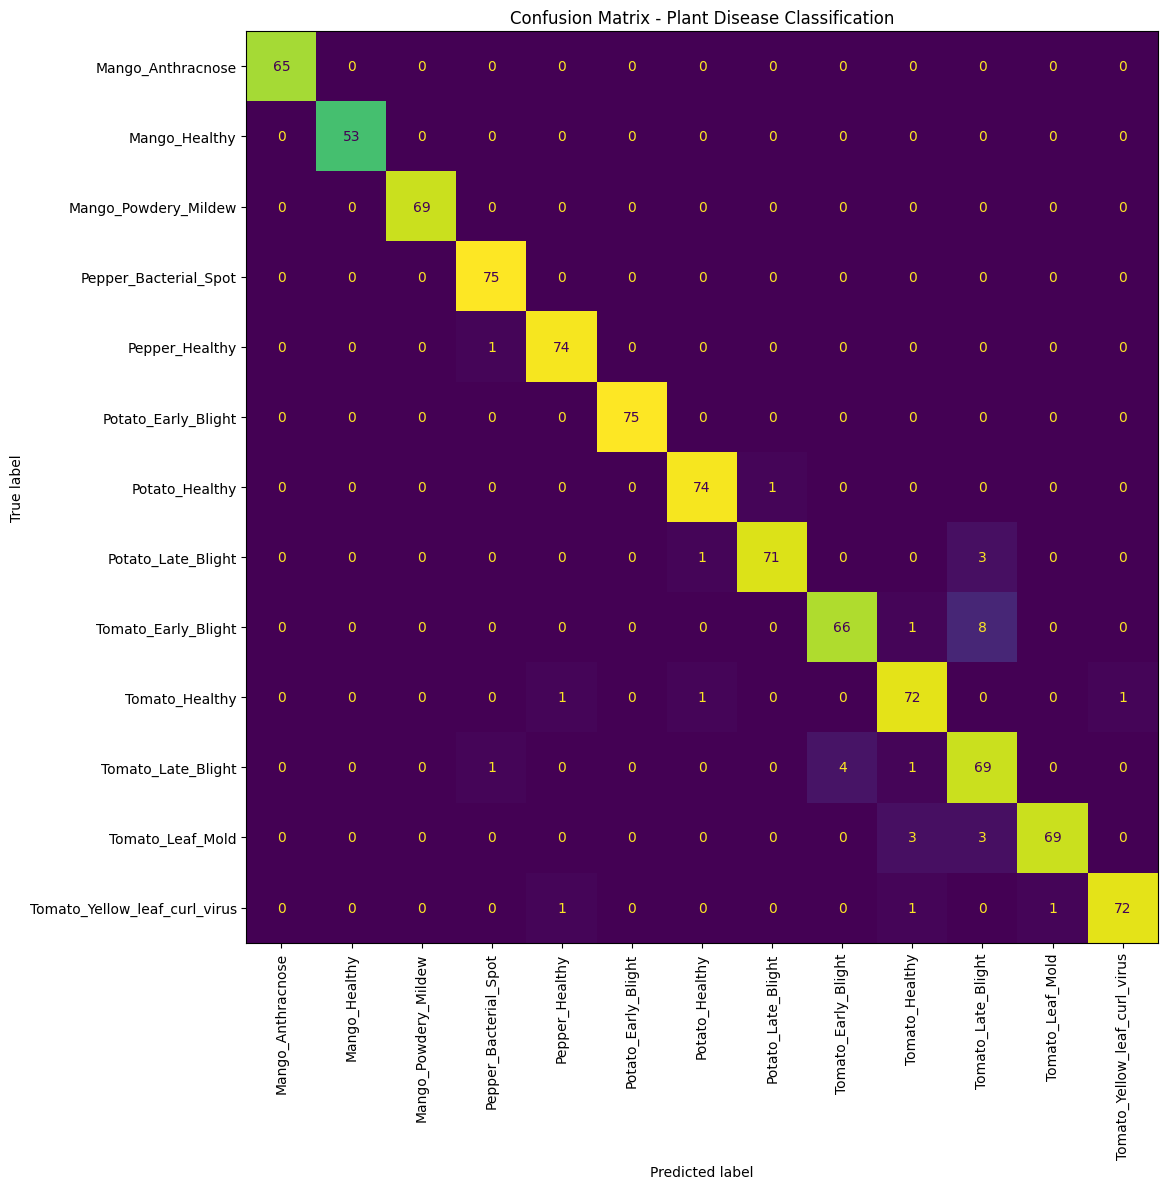

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models_second/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models_second/confusion_matrix.png", dpi=300, bbox_inches="tight")

### Testing on small dataset

Loaded class names:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Found 65 files belonging to 13 classes.

External dataset class names detected:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']


2026-03-24 00:41:05.984386: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 426ms/step

Classification Report on External Test Dataset:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    0.6000    0.7500         5
                Mango_Healthy     1.0000    0.4000    0.5714         5
         Mango_Powdery_Mildew     0.5000    0.2000    0.2857         5
        Pepper_Bacterial_Spot     0.5556    1.0000    0.7143         5
               Pepper_Healthy     0.7143    1.0000    0.8333         5
          Potato_Early_Blight     1.0000    0.4000    0.5714         5
               Potato_Healthy     0.3846    1.0000    0.5556         5
           Potato_Late_Blight     0.4286    0.6000    0.5000         5
          Tomato_Early_Blight     0.5000    0.2000    0.2857         5
               Tomato_Healthy     0.4286    0.6000    0.5000         5
           Tomato_Late_Blight     0.3333    0.6000    0.4286         5
             Tomato_Leaf_Mold     1.0000    0.2000    0.33

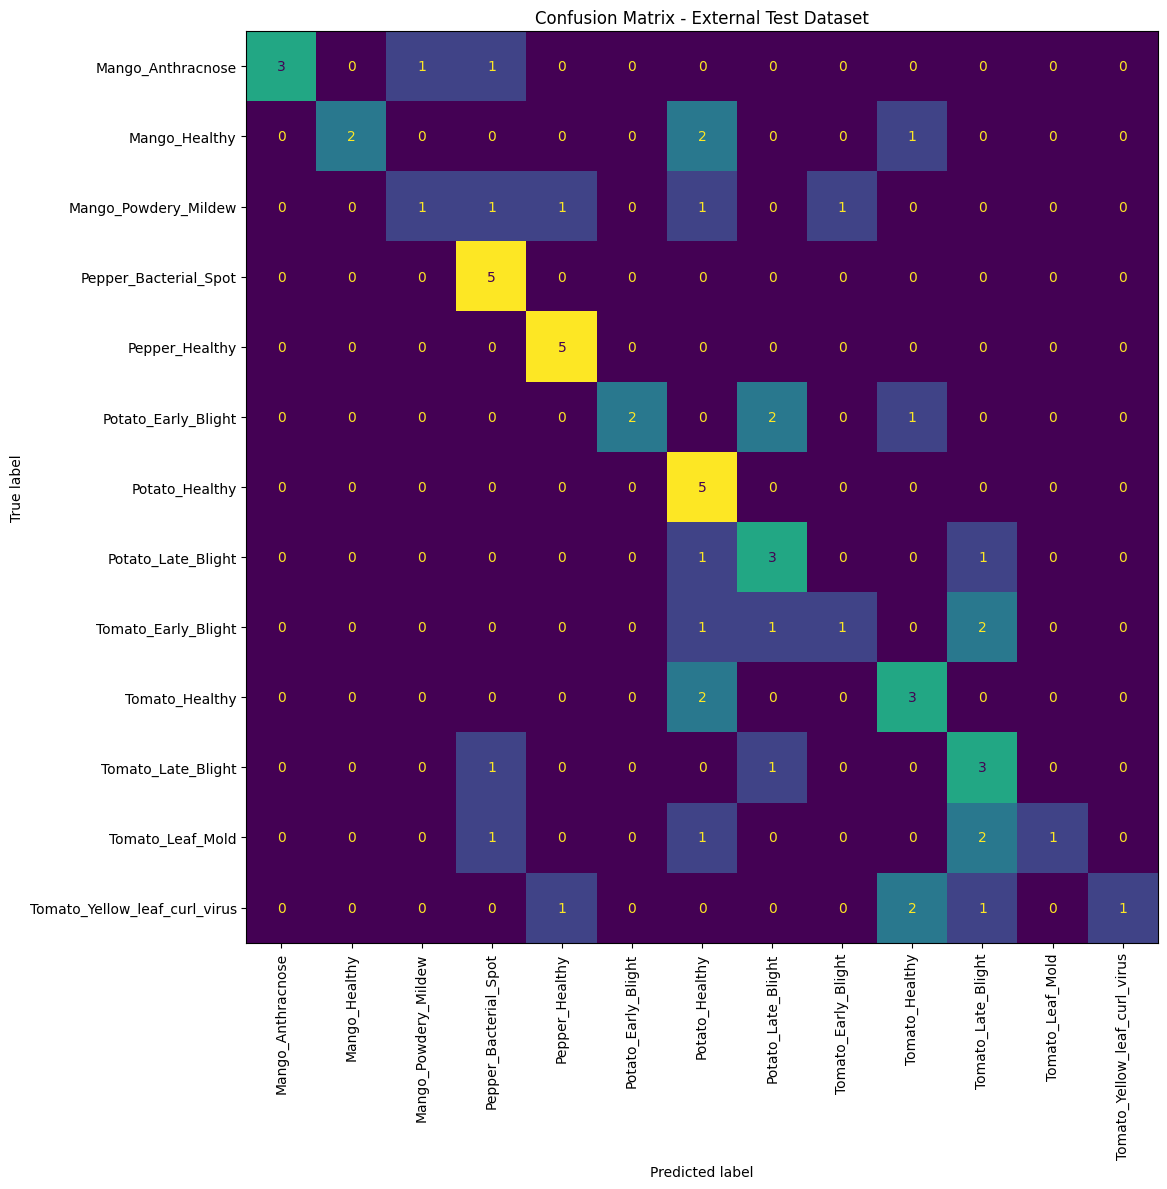


Per-image predictions:

File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0001.png
True: Mango_Anthracnose
Pred: Mango_Powdery_Mildew
Confidence: 0.8363
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0002.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 0.5813
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0003.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 0.9987
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0004.png
True: Mango_Anthra

In [5]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model.keras"
# /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras
CLASS_NAMES_PATH = "models_second/class_names.txt"
EXTERNAL_TEST_DIR = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset"

# ============================================================
# SETTINGS
# ============================================================
IMG_SIZE = (224, 224)
# IMG_SIZE = (300, 300)  # if model was trained with 300x300
BATCH_SIZE = 16

# ============================================================
# LOAD MODEL
# ============================================================
model = load_model(MODEL_PATH)

# ============================================================
# LOAD SAVED CLASS NAMES
# ============================================================
with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Loaded class names:")
print(class_names)

# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================
external_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    EXTERNAL_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nExternal dataset class names detected:")
print(external_ds_raw.class_names)

AUTOTUNE = tf.data.AUTOTUNE
external_ds = external_ds_raw.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# TRUE LABELS
# ============================================================
y_true = np.concatenate([y.numpy() for _, y in external_ds], axis=0)

# ============================================================
# PREDICTIONS
# ============================================================
y_pred_probs = model.predict(external_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report on External Test Dataset:\n")
print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - External Test Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# PER-IMAGE PREDICTIONS
# ============================================================
file_paths = []
for class_dir in sorted(Path(EXTERNAL_TEST_DIR).iterdir()):
    if class_dir.is_dir():
        for img_file in sorted(class_dir.iterdir()):
            if img_file.is_file():
                file_paths.append(str(img_file))

print("\nPer-image predictions:\n")
for i, path in enumerate(file_paths):
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])

    print(f"File: {path}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)

### Second training

In [6]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# PATHS
train_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/train"
val_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/val"
test_dir = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/plant_disease_dataset_second_split/test"

os.makedirs("models_second", exist_ok=True)

# SETTINGS
IMG_SIZE = (300, 300)
BATCH_SIZE = 16
SEED = 42

# DATA LOADERS
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# PERFORMANCE OPTIMISATION
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

# LIGHTER DATA AUGMENTATION
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

# BASE MODEL
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(300, 300, 3)
)

base_model.trainable = False

# BUILD MODEL
inputs = layers.Input(shape=(300, 300, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

# COMPILE STAGE 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# CALLBACKS STAGE 1
callbacks_stage1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_stage1_model_tuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# TRAIN STAGE 1
print("\nStarting Stage 1 training...")
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks_stage1
)

# LOAD BEST STAGE 1 WEIGHTS BEFORE FINE-TUNING
model.load_weights("models_second/best_stage1_model_tuned.keras")

# STAGE 2: FINE-TUNING
base_model.trainable = True

# Unfreeze only top 10–15% of layers
fine_tune_at = int(len(base_model.layers) * 0.9)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_stage2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="models_second/best_finetuned_model_tuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("\nStarting Stage 2 fine-tuning...")
history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks_stage2
)

# EVALUATE BEST STAGE 1 MODEL
print("\nEvaluating best Stage 1 model...")
stage1_best = tf.keras.models.load_model("models_second/best_stage1_model_tuned.keras")
stage1_loss, stage1_acc = stage1_best.evaluate(test_ds)
print(f"Best Stage 1 - Test Loss: {stage1_loss:.4f}")
print(f"Best Stage 1 - Test Accuracy: {stage1_acc:.4f}")

# EVALUATE BEST FINE-TUNED MODEL
print("\nEvaluating best fine-tuned model...")
stage2_best = tf.keras.models.load_model("models_second/best_finetuned_model_tuned.keras")
stage2_loss, stage2_acc = stage2_best.evaluate(test_ds)
print(f"Best Fine-Tuned - Test Loss: {stage2_loss:.4f}")
print(f"Best Fine-Tuned - Test Accuracy: {stage2_acc:.4f}")

# SAVE FINAL CHOSEN MODEL
if stage2_acc >= stage1_acc:
    final_model = stage2_best
    final_model_path = "models_second/plant_disease_model_final_tuned.keras"
    print("\nUsing fine-tuned model as final model.")
else:
    final_model = stage1_best
    final_model_path = "models_second/plant_disease_model_final_tuned.keras"
    print("\nUsing Stage 1 model as final model.")

final_model.save(final_model_path)
print(f"Final model saved to: {final_model_path}")

# SAVE CLASS NAMES
class_names_path = "models_second/class_names_tuned.txt"
with open(class_names_path, "w", encoding="utf-8") as f:
    for name in class_names:
        f.write(name + "\n")

print(f"Class names saved to: {class_names_path}")

Found 4361 files belonging to 13 classes.
Found 936 files belonging to 13 classes.
Found 937 files belonging to 13 classes.
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Number of classes: 13

Starting Stage 1 training...
Epoch 1/12
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.7418 - loss: 0.8891
Epoch 1: val_loss improved from None to 0.17907, saving model to models_second/best_stage1_model_tuned.keras

Epoch 1: finished saving model to models_second/best_stage1_model_tuned.keras
273/273 ━━━━━━━━━━━━━━━━━━━━ 140s 496ms/step - accuracy: 0.8370 - loss: 0.5443 - val_accuracy: 0.9455 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 2/12
273/273 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9238 - loss: 0.2333
Epoch 2: val_loss imp

### Comparison between the two models

Two main training configurations were compared. The first achieved a best held-out test accuracy of 95.62%, while the second improved this to 98.29%. In both experiments, the frozen-backbone Stage 1 model outperformed the fine-tuned Stage 2 model, indicating that transfer learning with the EfficientNet-B0 feature extractor preserved stronger generalisation than partial unfreezing in this dataset setting.

### Confusion Matrix for 2nd training model

59/59 ━━━━━━━━━━━━━━━━━━━━ 25s 405ms/step
Classes: ['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']

Classification Report:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    1.0000    1.0000        65
                Mango_Healthy     1.0000    1.0000    1.0000        53
         Mango_Powdery_Mildew     1.0000    1.0000    1.0000        69
        Pepper_Bacterial_Spot     1.0000    1.0000    1.0000        75
               Pepper_Healthy     0.9615    1.0000    0.9804        75
          Potato_Early_Blight     1.0000    1.0000    1.0000        75
               Potato_Healthy     0.9737    0.9867    0.9801        75
           Potato_Late_Blight     0.9861    0.9467    0.9660        75

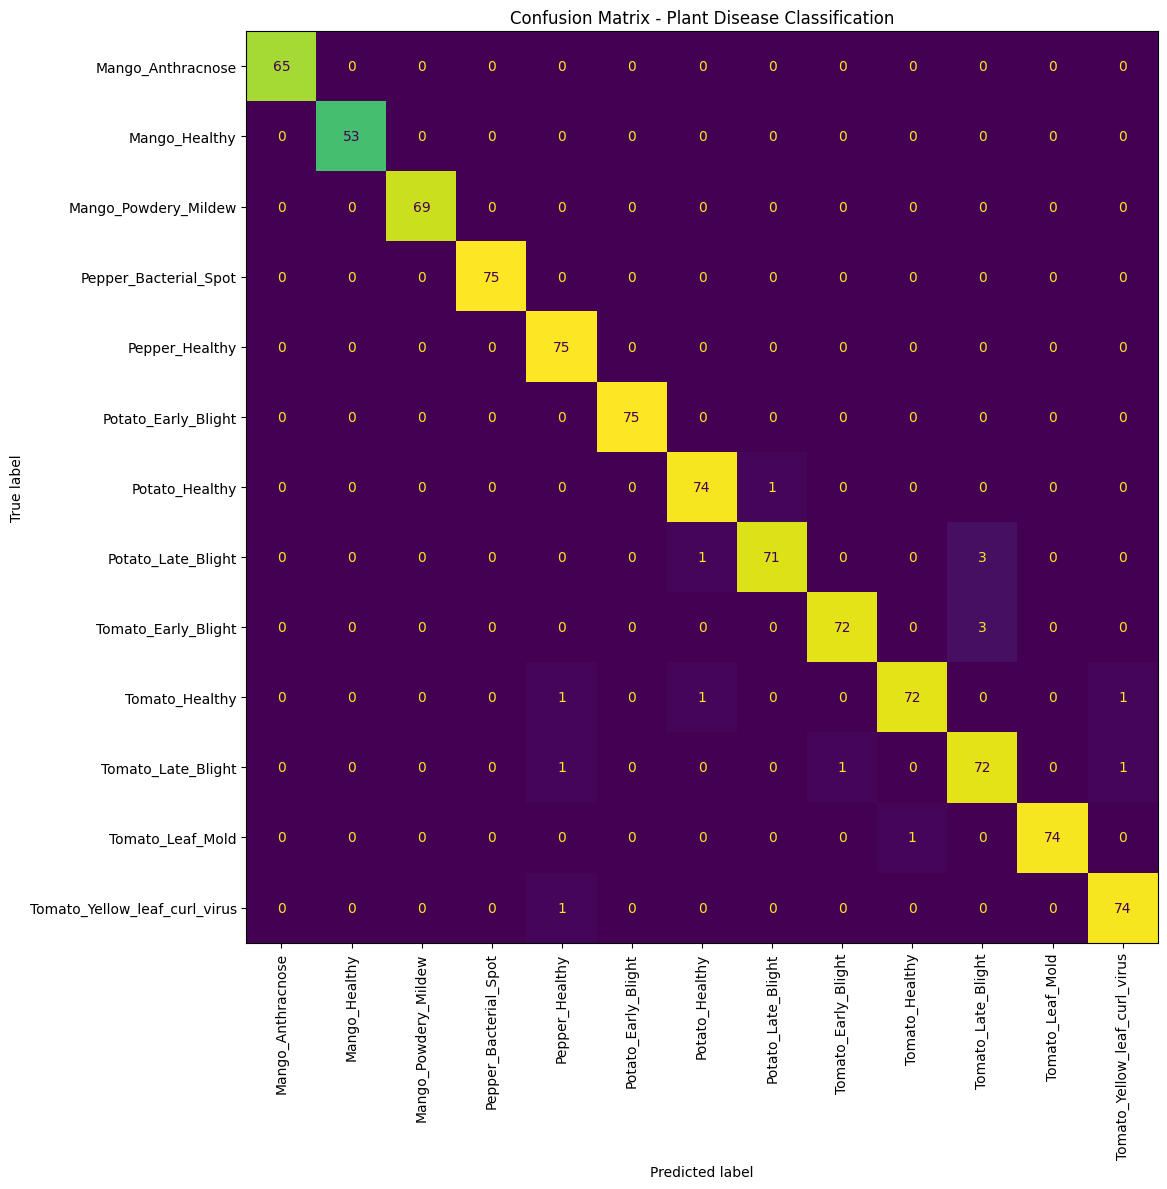

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# LOAD BEST MODEL
model = load_model("/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras")

# GET TRUE LABELS
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# GET PREDICTIONS
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# CLASS NAMES
with open("models_second/class_names.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]
print("Classes:", class_names)

# CLASSIFICATION REPORT
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report:\n")
print(report)

# Optional: save report to a text file
with open("models_second/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

# CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - Plant Disease Classification")
plt.tight_layout()
plt.show()

# Optional: save confusion matrix image
fig.savefig("models_second/confusion_matrix.png", dpi=300, bbox_inches="tight")

### Testing on mini_dataset for 2nd model

Loaded class names:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']
Found 65 files belonging to 13 classes.

External dataset class names detected:
['Mango_Anthracnose', 'Mango_Healthy', 'Mango_Powdery_Mildew', 'Pepper_Bacterial_Spot', 'Pepper_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Yellow_leaf_curl_virus']


2026-03-24 01:50:19.979510: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 562ms/step

Classification Report on External Test Dataset:

                               precision    recall  f1-score   support

            Mango_Anthracnose     1.0000    0.6000    0.7500         5
                Mango_Healthy     1.0000    0.4000    0.5714         5
         Mango_Powdery_Mildew     0.6667    0.4000    0.5000         5
        Pepper_Bacterial_Spot     0.7143    1.0000    0.8333         5
               Pepper_Healthy     0.7143    1.0000    0.8333         5
          Potato_Early_Blight     0.2500    0.2000    0.2222         5
               Potato_Healthy     0.2941    1.0000    0.4545         5
           Potato_Late_Blight     0.3333    0.2000    0.2500         5
          Tomato_Early_Blight     0.0000    0.0000    0.0000         5
               Tomato_Healthy     0.3333    0.6000    0.4286         5
           Tomato_Late_Blight     0.5000    0.4000    0.4444         5
             Tomato_Leaf_Mold     1.0000    0.2000    0.33

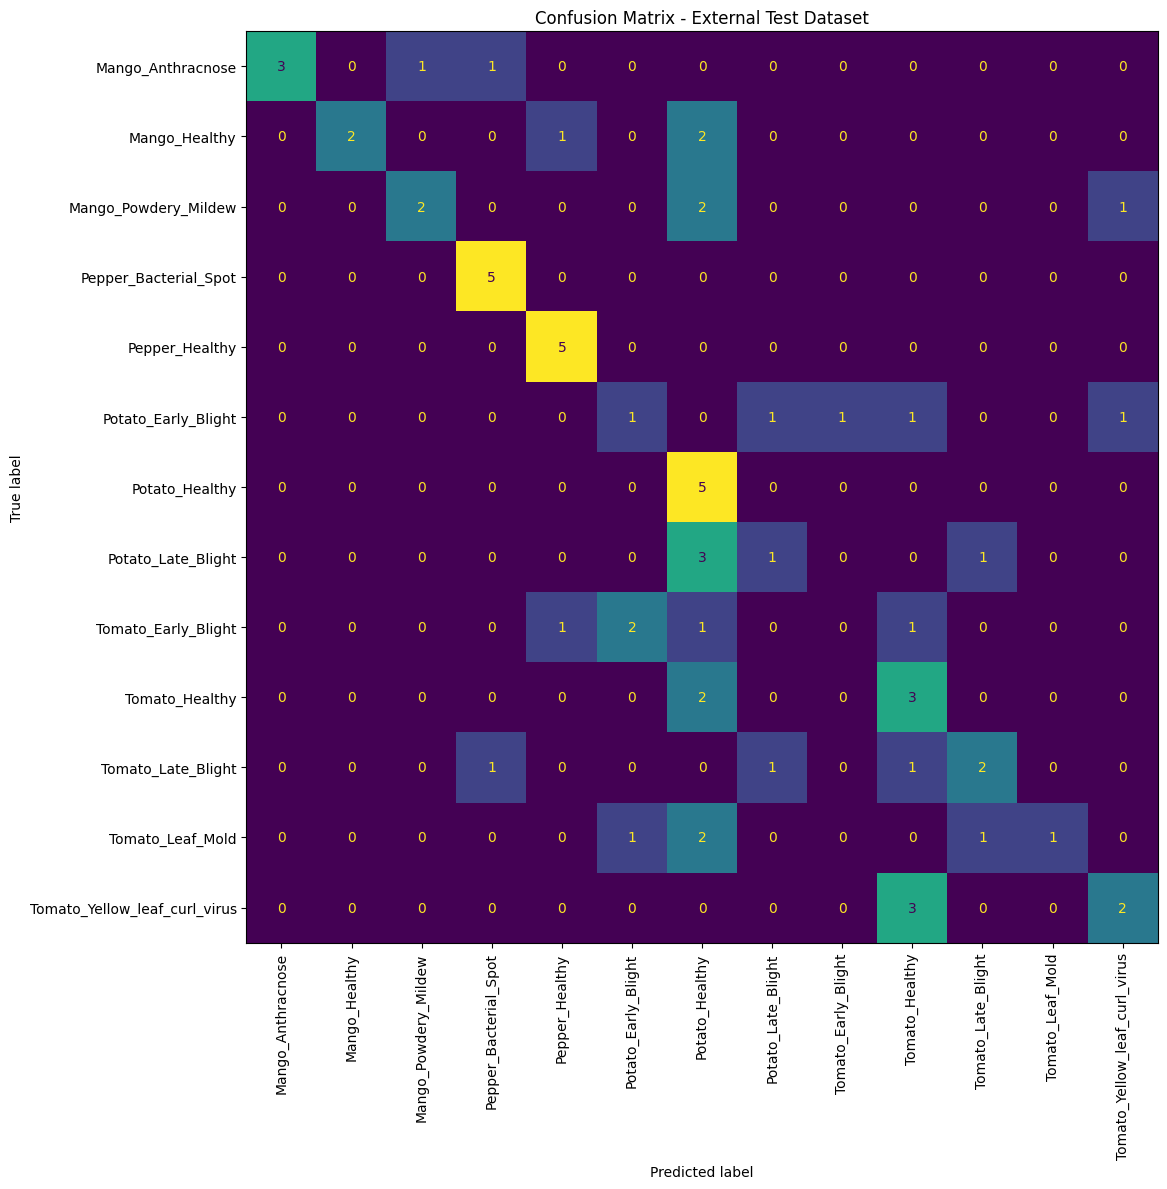


Per-image predictions:

File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0001.png
True: Mango_Anthracnose
Pred: Mango_Powdery_Mildew
Confidence: 0.9755
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0002.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0003.png
True: Mango_Anthracnose
Pred: Mango_Anthracnose
Confidence: 1.0000
--------------------------------------------------
File: /Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset/Mango_Anthracnose/Mango_Anthracnose_0004.png
True: Mango_Anthra

In [8]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import load_model

# ============================================================
# PATHS
# ============================================================
MODEL_PATH = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/models_second/best_stage1_model_tuned.keras"
CLASS_NAMES_PATH = "models_second/class_names_tuned.txt"
EXTERNAL_TEST_DIR = "/Users/adrianpothanah/Plant_Disease_Management_System/Plant-Disease-Management-System/mini_dataset"

# ============================================================
# SETTINGS
# ============================================================
#IMG_SIZE = (224, 224)
IMG_SIZE = (300, 300)  # if model was trained with 300x300
BATCH_SIZE = 16

# ============================================================
# LOAD MODEL
# ============================================================
model = load_model(MODEL_PATH)

# ============================================================
# LOAD SAVED CLASS NAMES
# ============================================================
with open(CLASS_NAMES_PATH, "r", encoding="utf-8") as f:
    class_names = [line.strip() for line in f.readlines()]

print("Loaded class names:")
print(class_names)

# ============================================================
# LOAD EXTERNAL DATASET
# ============================================================
external_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    EXTERNAL_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nExternal dataset class names detected:")
print(external_ds_raw.class_names)

AUTOTUNE = tf.data.AUTOTUNE
external_ds = external_ds_raw.prefetch(buffer_size=AUTOTUNE)

# ============================================================
# TRUE LABELS
# ============================================================
y_true = np.concatenate([y.numpy() for _, y in external_ds], axis=0)

# ============================================================
# PREDICTIONS
# ============================================================
y_pred_probs = model.predict(external_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("\nClassification Report on External Test Dataset:\n")
print(report)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("Confusion Matrix - External Test Dataset")
plt.tight_layout()
plt.show()

# ============================================================
# PER-IMAGE PREDICTIONS
# ============================================================
file_paths = []
for class_dir in sorted(Path(EXTERNAL_TEST_DIR).iterdir()):
    if class_dir.is_dir():
        for img_file in sorted(class_dir.iterdir()):
            if img_file.is_file():
                file_paths.append(str(img_file))

print("\nPer-image predictions:\n")
for i, path in enumerate(file_paths):
    true_label = class_names[y_true[i]]
    pred_label = class_names[y_pred[i]]
    confidence = np.max(y_pred_probs[i])

    print(f"File: {path}")
    print(f"True: {true_label}")
    print(f"Pred: {pred_label}")
    print(f"Confidence: {confidence:.4f}")
    print("-" * 50)